In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# Building dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
    X, Y = [], []
    for w in words:

        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)

    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [5]:
# MLP Revisited
n_embd = 10 # dimensionality of the embedding vectors
n_hidden = 200 # number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size) ** 0.5)
# b1 does nothing as a result of batch noramilzation, can safely remove
# b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

# Batch norm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

params = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in params)) # num of total params
for p in params:
    p.requires_grad = True

12097


In [ ]:
# Optimization
num_steps = 200000
batch_size = 32
lossi = []
eps = 1e-5

for i in range(num_steps):

    # minibatch construct for faster training using batches of size 32
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb = Xtr[ix], Ytr[ix] # Batch X and Y

    # forward pass
    emb = C[Xb] # embed into vectors
    embcat = emb.view(emb.shape[0], -1) # concatinate vectors
    hpreact = embcat @ W1 # + b1 # hidden layer pre-activation

    # batch normalization layer
    # ---------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain* (hpreact - bnmeani)/(bnstdi + eps) + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    # ---------------------------------------------------------
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) #loss function


    # backward pass
    for p in params:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay
    for p in params:
        p.data += -lr * p.grad

    # STAT TRACKING
    # print loss every once in a while
    if i % 10000 == 0:
        print(f'{i:7d}/{num_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


print(loss.item())

      0/ 200000: 3.3206
  10000/ 200000: 2.3471
  20000/ 200000: 2.3301
  30000/ 200000: 2.4522
  40000/ 200000: 2.2149
  50000/ 200000: 2.2271
  60000/ 200000: 2.2762
  70000/ 200000: 1.8637
  80000/ 200000: 2.3327
  90000/ 200000: 2.0936
 100000/ 200000: 1.9735
 110000/ 200000: 1.7748
 120000/ 200000: 1.9787
 130000/ 200000: 1.8759
 140000/ 200000: 1.9612
 150000/ 200000: 1.9370
 160000/ 200000: 2.2018
 170000/ 200000: 2.5746
 180000/ 200000: 2.0015
 190000/ 200000: 2.4635
1.862646222114563


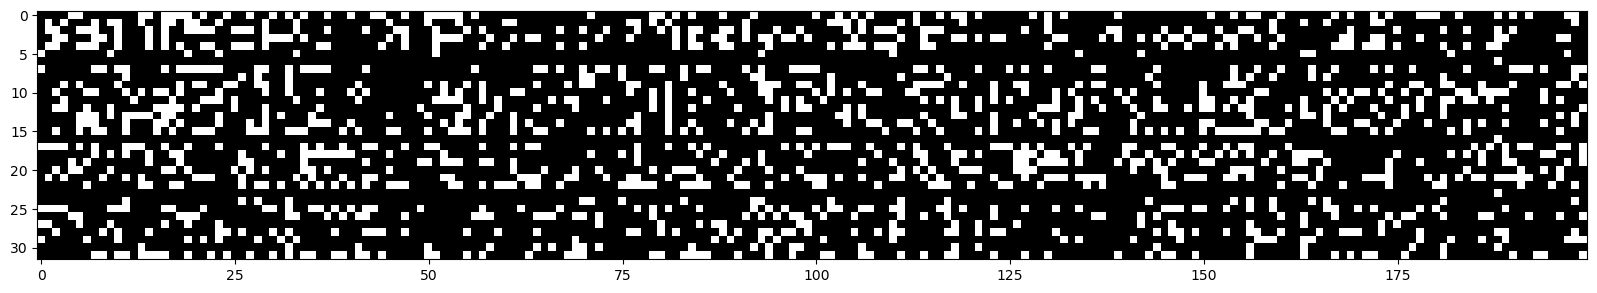

In [37]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap = 'gray', interpolation='nearest')

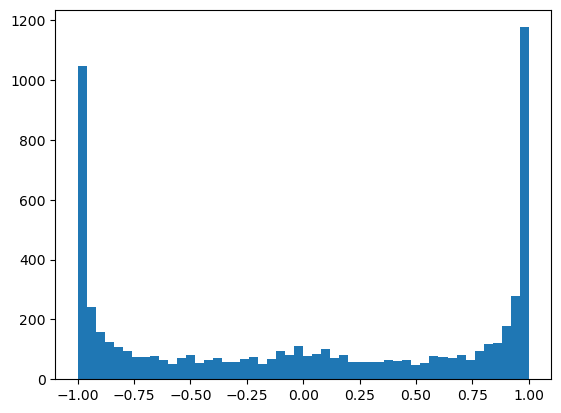

In [38]:
plt.hist(h.view(-1).tolist(), 50);

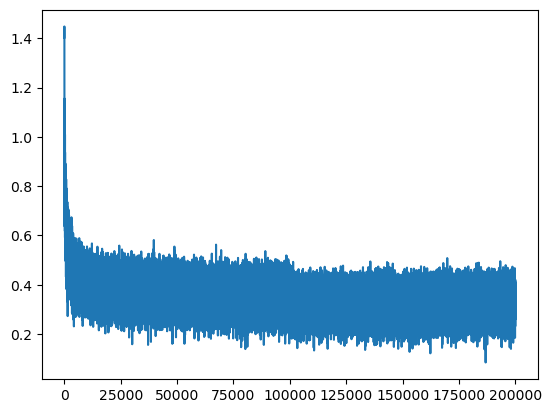

In [10]:
plt.plot(lossi)

In [7]:
@torch.no_grad() # decorator disables gradient tracking, makes the function much more efficient
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    emb = C[x] #Size (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) #concat info (N, block_size * n_embd)
    hpreact = embcat @ W1 # hidden layer pre-activation

    # batch normalization
    hpreact = bngain* (hpreact - bnmean_running)/(bnstd_running) + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 #(N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0720388889312744
val 2.11185884475708


In [ ]:
# Sampling from the model 
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialization [.] * block_size
    while True:
        # forward pass
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples = 1, generator = g).item()

        # shift context window and track samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special token '.', then break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out)) #decode and print out the generated word 

carmah.
amille.
khy.
mili.
thil.
halaysie.
rah.
bradherric.
kaeli.
ner.
kiah.
maiivie.
legy.
hali.
pois.
quinn.
shonne.
liveni.
watelo.
dearynix.


In [16]:
# Torchifying code
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        self.weight = torch.randn((fan_in, fan_out), generator= g) / fan_in ** 0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    

class BatchNorm1d:

    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # buffers
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # forward pass
        if self.training:
            xmean = x.mean(0, keepdim = True) # batch mean
            xvar = x.var(0, keepdim = True, unbiased = True) # batch varience

        else:
            xmean = self.running_mean
            xvar = self.running_std
        
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize
        self.out = self.gamma * xhat + self.beta
        # update buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []
    

# Creating our neural network

n_embd = 10 # dimensionality of the embedding vectors
n_hidden = 200 # number of neurons in the hidden layer

# to replicate results
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),            BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),            BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),            BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),            BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size)
]

with torch.no_grad():
    # make last layer less confident
    layers[-1].gamma *= 0.1
    # Apply gain to all other layers
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


174751


In [9]:
# Optimization
num_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(num_steps):

    # minibatch construct for faster training using batches of size 32
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb = Xtr[ix], Ytr[ix] # Batch X and Y

    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)


    # backward pass
    for layer in layers:
        # This is for debugging, should be removed once done. 
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # STAT TRACKING
    # print loss every once in a while
    if i % 10000 == 0:
        print(f'{i:7d}/{num_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i > 1000:
        break # removed after done debugging to run full optimization

      0/ 200000: 3.3000


layer 2 (      Tanh): mean -0.01, std 0.63, saturated: 2.66%
layer 5 (      Tanh): mean +0.00, std 0.64, saturated: 2.66%
layer 8 (      Tanh): mean -0.00, std 0.64, saturated: 2.62%
layer 11 (      Tanh): mean +0.00, std 0.64, saturated: 2.66%
layer 14 (      Tanh): mean +0.00, std 0.64, saturated: 2.31%


Text(0.5, 1.0, 'activation distribution')

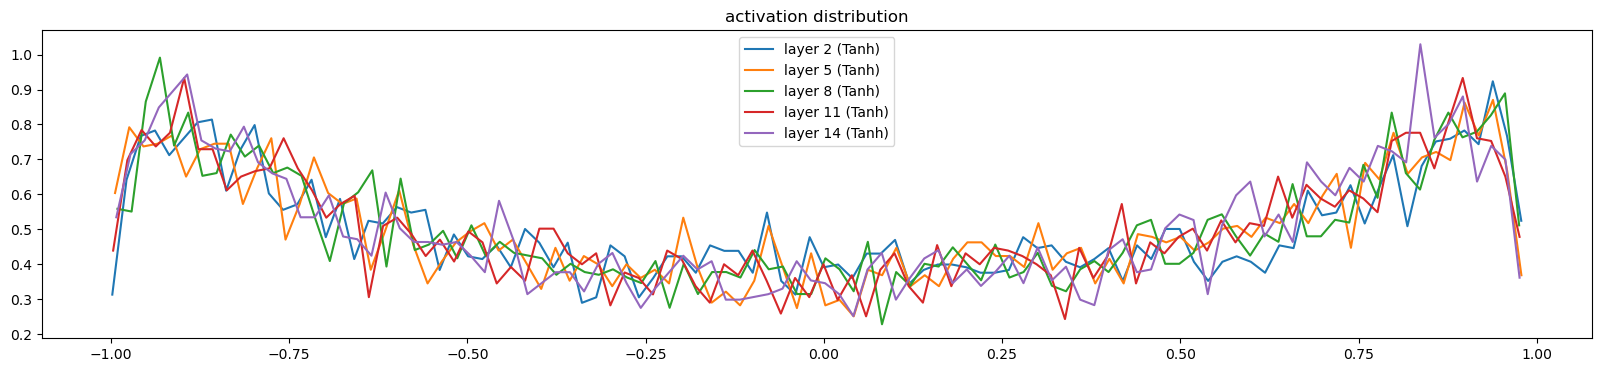

In [94]:
# histogram visualization
plt.figure(figsize = (20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # exclude output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() *100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 2.170272e-03
layer 5 (      Tanh): mean -0.000000, std 1.845132e-03
layer 8 (      Tanh): mean -0.000000, std 1.731273e-03
layer 11 (      Tanh): mean -0.000000, std 1.579160e-03
layer 14 (      Tanh): mean -0.000000, std 1.523157e-03


Text(0.5, 1.0, 'gradient distribution')

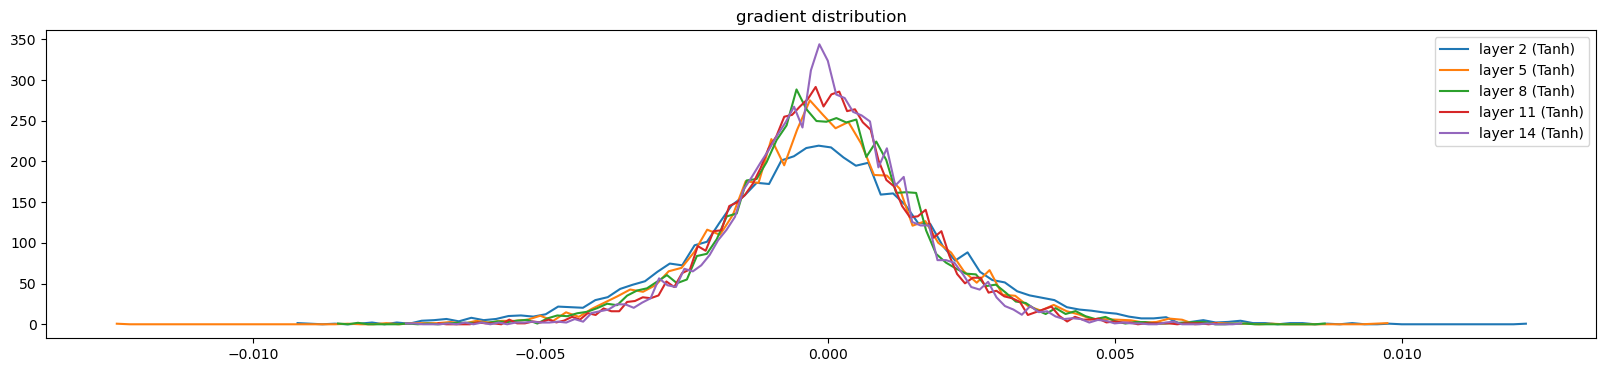

In [95]:
# histogram visualization
plt.figure(figsize = (20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # exclude output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 9.453668e-03 | grad:data ratio 9.443833e-03
weight  (30, 200) | mean -0.000088 | std 5.312352e-03 | grad:data ratio 1.707995e-02
weight (200, 200) | mean -0.000017 | std 4.366041e-03 | grad:data ratio 3.688271e-02
weight (200, 200) | mean -0.000020 | std 3.798889e-03 | grad:data ratio 3.215807e-02
weight (200, 200) | mean -0.000002 | std 3.383639e-03 | grad:data ratio 2.851216e-02
weight (200, 200) | mean +0.000003 | std 3.204851e-03 | grad:data ratio 2.718415e-02
weight  (200, 27) | mean +0.000019 | std 8.672103e-03 | grad:data ratio 7.195410e-02


Text(0.5, 1.0, 'weights gradient distribution')

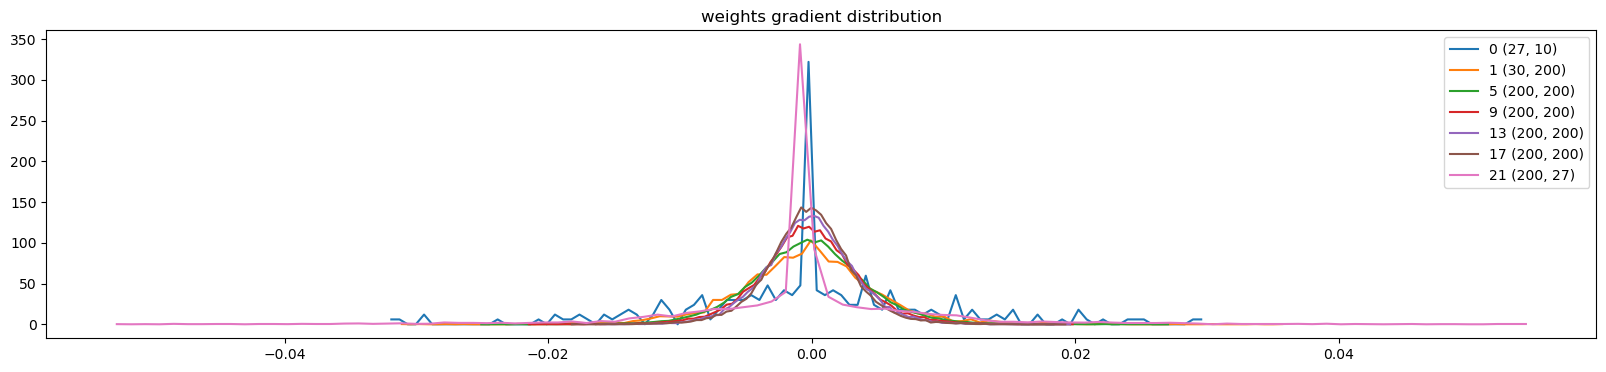

In [96]:
# histogram visualization
plt.figure(figsize = (20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std()/p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
        
plt.legend(legends)
plt.title('weights gradient distribution')

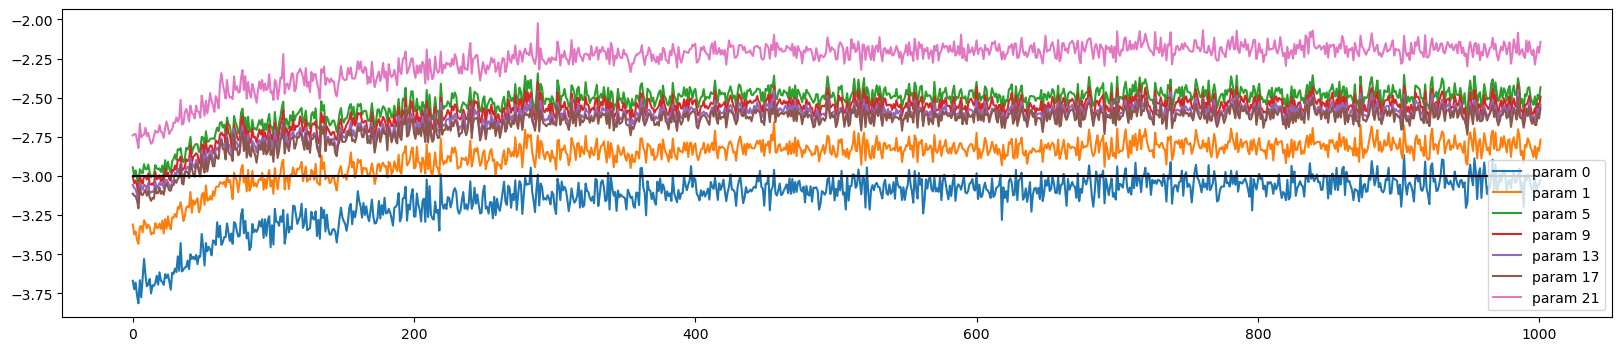

In [97]:
# histogram visualization
plt.figure(figsize = (20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
    
plt.plot([0, len(ud)], [-3, -3], 'k') # rations should be abt 1e-3
plt.legend(legends);

# Exercises

E01: I did not get around to seeing what happens when you initialize all weights and biases to zero. Try this and train the neural net. You might think either that 
1) the network trains just fine or 
2) the network doesn't train at all, but actually it is 
3) the network trains but only partially, and achieves a pretty bad final performance. Inspect the gradients and activations to figure out what is happening and why the network is only partially training, and what part is being trained exactly. 

In [ ]:
# MLP Revisited
n_embd = 10 # dimensionality of the embedding vectors
n_hidden = 200 # number of neurons in the hidden layer

g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.zeros((n_embd * block_size, n_hidden))
W2 = torch.zeros((n_hidden, vocab_size))
b2 = torch.zeros((vocab_size))

# Batch norm parameters
bngain = torch.ones((1, n_hidden))
bnbias = torch.zeros((1, n_hidden))
bnmean_running = torch.zeros((1, n_hidden))
bnstd_running = torch.ones((1, n_hidden))

params = [C, W1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in params)) # num of total params
for p in params:
    p.requires_grad = True

# Optimization
num_steps = 200000
batch_size = 32
lossi = []
eps = 1e-5

for i in range(num_steps):

    # minibatch construct for faster training using batches of size 32
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb = Xtr[ix], Ytr[ix] # Batch X and Y

    # forward pass
    emb = C[Xb] # embed into vectors
    embcat = emb.view(emb.shape[0], -1) # concatinate vectors
    hpreact = embcat @ W1 # + b1 # hidden layer pre-activation

    # batch normalization layer
    # ---------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain* (hpreact - bnmeani)/(bnstdi + eps) + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

    # ---------------------------------------------------------
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) #loss function


    # backward pass
    for p in params:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay
    for p in params:
        p.data += -lr * p.grad

    # STAT TRACKING
    # print loss every once in a while
    if i % 10000 == 0:
        print(f'{i:7d}/{num_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())


print(loss.item())

12097
      0/ 200000: 3.2958
  10000/ 200000: 2.5978
  20000/ 200000: 2.6048
  30000/ 200000: 3.0172
  40000/ 200000: 2.7718
  50000/ 200000: 2.6617
  60000/ 200000: 2.5590
  70000/ 200000: 2.8529
  80000/ 200000: 2.8118
  90000/ 200000: 2.6709
 100000/ 200000: 2.7227
 110000/ 200000: 2.7358
 120000/ 200000: 2.7542
 130000/ 200000: 2.8930
 140000/ 200000: 3.1221
 150000/ 200000: 2.6391
 160000/ 200000: 2.5792
 170000/ 200000: 2.8564
 180000/ 200000: 2.6347
 190000/ 200000: 2.8848
3.07719087600708


In [76]:
@torch.no_grad() # decorator disables gradient tracking, makes the function much more efficient
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    emb = C[x] #Size (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) #concat info (N, block_size * n_embd)
    hpreact = embcat @ W1 # hidden layer pre-activation

    # batch normalization
    hpreact = bngain* (hpreact - bnmean_running)/(bnstd_running) + bnbias
    h = torch.tanh(hpreact) # (N, n_hidden)
    logits = h @ W2 + b2 #(N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())


# Getting overall loss
# Note best loss prev was around 2.10 for val
split_loss('train')
split_loss('val')



train 2.8226935863494873
val 2.82106351852417


In [ ]:
# Sampling from the model

"""
Previous names:
carmah.
amille.
khy.
mili.
thil.
halaysie.
rah.
bradherric.
kaeli.
ner.
kiah.
maiivie.
legy.
hali.
pois.
quinn.
shonne.
liveni.
watelo.
dearynix.
"""


g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialization [.] * block_size
    while True:
        # forward pass
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples = 1, generator = g).item()

        # shift context window and track samples
        context = context[1:] + [ix]
        out.append(ix)
        # if we sample the special token '.', then break
        if ix == 0:
            break
    
    print(''.join(itos[i] for i in out)) #decode and print out the generated word 

narmahxaae.
hlrihkimrs.
reaty.
hnaassnejr.
hnenfamesahc.
iaeei.
.
ermaia.
ceaiiv.
e.
lein.
h.
.
m.
.
oin.
eeijn.
s.
lilea.
.


So loss becomes worse overall, closer to what we had with the bigram language model. Lets inspect the gradients and activations.

In [ ]:
# Using classes for torchifying
# Creating our neural network

n_embd = 10 # dimensionality of the embedding vectors
n_hidden = 200 # number of neurons in the hidden layer

# to replicate results
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),            BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),            BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),            BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),            BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size)
]

with torch.no_grad():
    # make last layer less confident
    layers[-1].gamma *= 0.1
    # Apply gain to all other layers
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            # Make all weights and biases 0
            layer.weight *= 0.0
            layer.bias *= 0.0
            print(layer.weight)
            print(layer.bias)

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

tensor([[-0., 0., -0.,  ..., -0., 0., 0.],
        [-0., -0., -0.,  ..., 0., -0., -0.],
        [-0., 0., -0.,  ..., 0., -0., -0.],
        ...,
        [0., 0., -0.,  ..., -0., 0., 0.],
        [-0., -0., 0.,  ..., 0., -0., -0.],
        [-0., 0., -0.,  ..., 0., -0., -0.]])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [106]:
# Optimization
num_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(num_steps):

    # minibatch construct for faster training using batches of size 32
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb = Xtr[ix], Ytr[ix] # Batch X and Y

    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)


    # backward pass
    for layer in layers:
        # This is for debugging, should be removed once done. 
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # STAT TRACKING
    # print loss every once in a while
    if i % 10000 == 0:
        print(f'{i:7d}/{num_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break # removed after done debugging to run full optimization

print(loss.item())

      0/ 200000: 3.2958
2.8204288482666016


layer 2 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 8 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 2 (      Tanh): mean +0.000000, std 0.000000e+00
layer 5 (      Tanh): mean +0.000000, std 0.000000e+00
layer 8 (      Tanh): mean +0.000000, std 0.000000e+00
weight   (27, 10) | mean +0.000000 | std 0.000000e+00 | grad:data ratio 0.000000e+00
weight  (30, 200) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (200, 200) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (200, 200) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight  (200, 27) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan


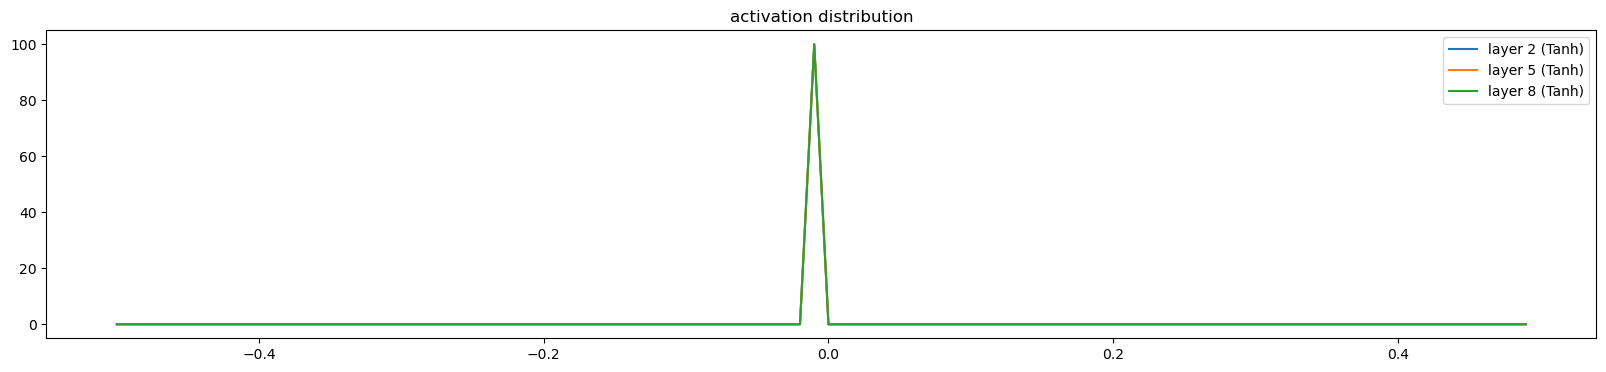

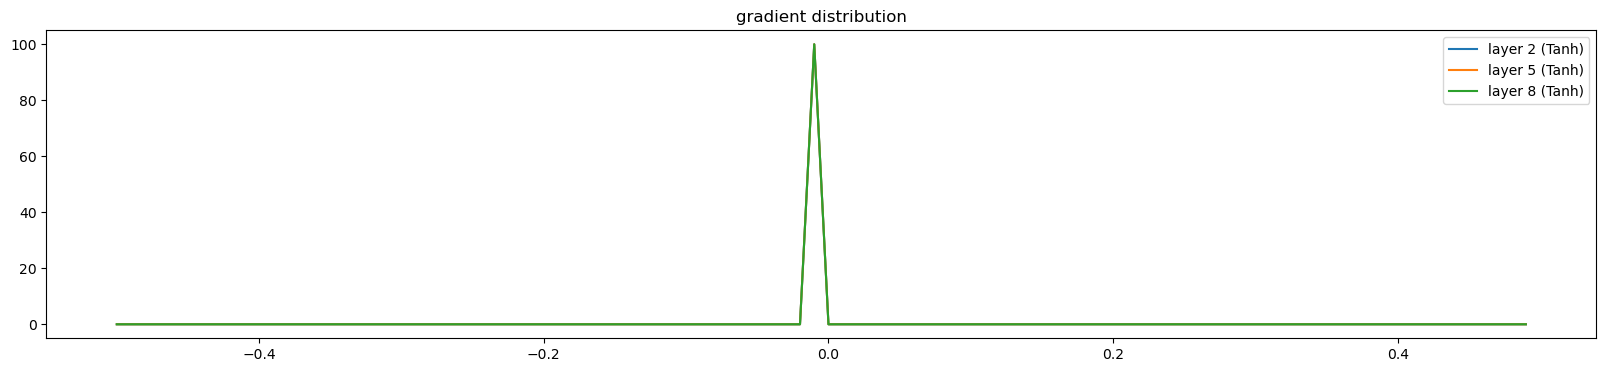

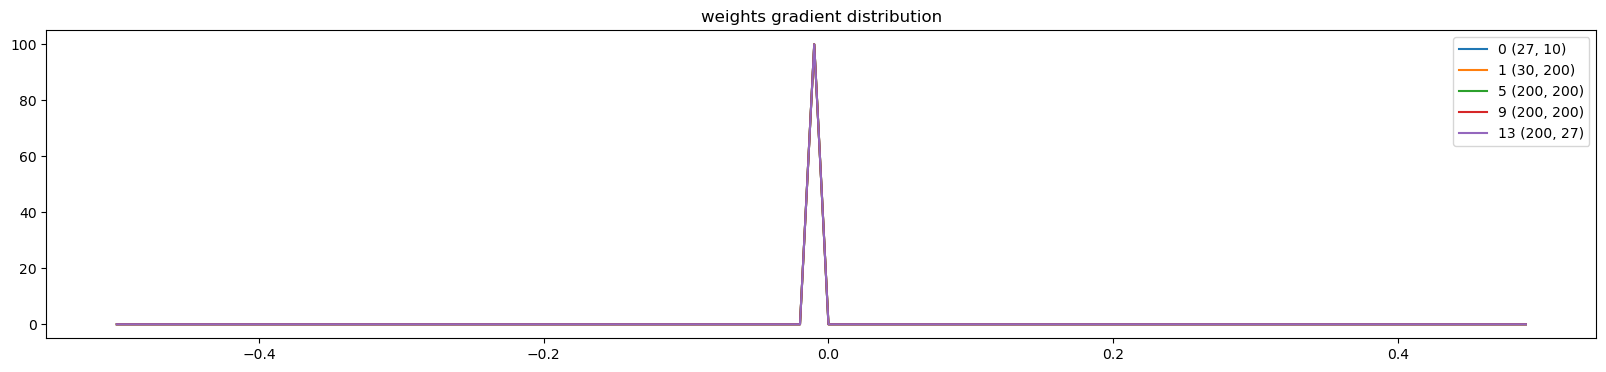

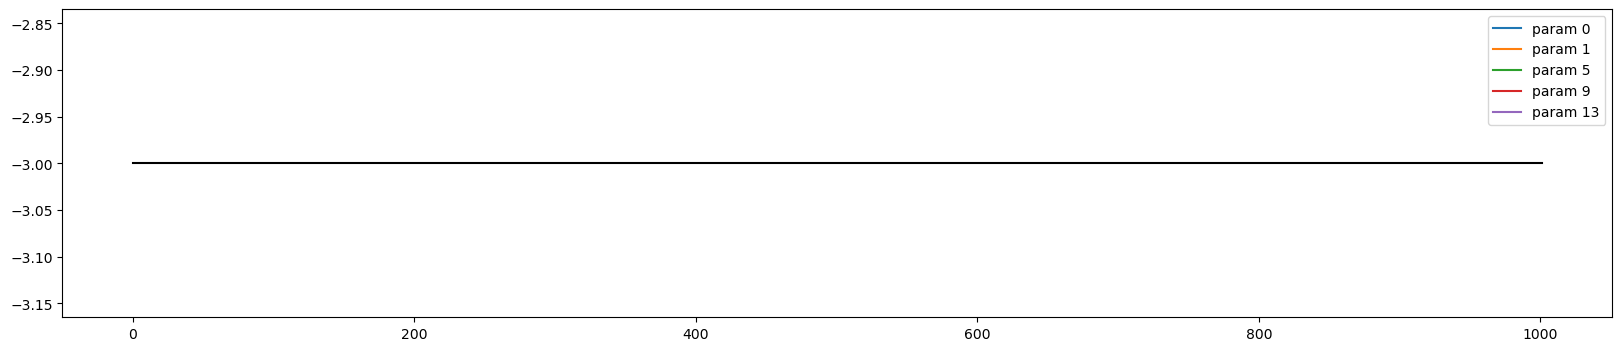

In [107]:
# histogram visualization
plt.figure(figsize = (20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # exclude output layer
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() *100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

plt.figure(figsize = (20, 4))
legends = []
for i, layer in enumerate(layers[:-1]): # exclude output layer
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution')

plt.figure(figsize = (20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std()/p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i} {tuple(p.shape)}')
        
plt.legend(legends)
plt.title('weights gradient distribution')

plt.figure(figsize = (20, 4))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append('param %d' % i)
    
plt.plot([0, len(ud)], [-3, -3], 'k') # rations should be abt 1e-3
plt.legend(legends);

With all weights and biases set to zero, we see that each layer recieves the same update throughout backprop. So while loss seems to be going down, the model is not really learning.  

E02: BatchNorm, unlike other normalization layers like LayerNorm/GroupNorm etc. has the big advantage that after training, the batchnorm gamma/beta can be "folded into" the weights of the preceeding Linear layers, effectively erasing the need to forward it at test time. Set up a small 3-layer MLP with batchnorms, train the network, then "fold" the batchnorm gamma/beta into the preceeding Linear layer's W,b by creating a new W2, b2 and erasing the batch norm. Verify that this gives the same forward pass during inference. i.e. we see that the batchnorm is there just for stabilizing the training, and can be thrown out after training is done! pretty cool.


In [18]:
# 3 layer MLP

n_embd = 10 # dimensionality of the embedding vectors
n_hidden = 200 # number of neurons in the hidden layer

# to replicate results
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator=g)
layers = [
    Linear(n_embd * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, n_hidden),            BatchNorm1d(n_hidden), Tanh(),
    Linear(n_hidden, vocab_size), BatchNorm1d(vocab_size)
]

with torch.no_grad():
    # make last layer less confident
    layers[-1].gamma *= 0.1
    # Apply gain to all other layers
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

52951


In [19]:
# train first
num_steps = 20000
batch_size = 32
lossi = []
ud = []

for i in range(num_steps):

    # minibatch construct for faster training using batches of size 32
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb = Xtr[ix], Ytr[ix] # Batch X and Y

    # forward pass
    emb = C[Xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)


    # backward pass
    for layer in layers:
        # This is for debugging, should be removed once done. 
        layer.out.retain_grad()

    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01 # learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # STAT TRACKING
    # print loss every once in a while
    if i % 10000 == 0:
        print(f'{i:7d}/{num_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

print(loss.item())

      0/  20000: 3.3040
  10000/  20000: 2.0131
2.3427040576934814


In [20]:
# Now we 'fold' the gamma/beta into the preceding linear layer and remove the batchnorm layers
# We do this by fusing into a single linear layer

new_layers = []
for i in range(len(layers)):
    if isinstance(layers[i], BatchNorm1d):
        # Create fused layer
        bn = layers[i]
        gamma, beta = bn.gamma, bn.beta
        rmean, rvar = bn.running_mean, bn.running_var
        W = layers[i - 1].weight
        b = layers[i - 1].bias

        W_fused = W * gamma/(torch.sqrt(rvar + 1e-5))
        b_fused = (b - rmean) * (gamma/(torch.sqrt(rvar + 1e-5))) + beta

        new_layer = Linear(W.shape[0], W.shape[1])
        new_layer.weight = W_fused
        new_layer.bias = b_fused

        new_layers.append(new_layer)
        if i != len(layers) - 1:
            new_layers.append(Tanh())

print([i.__class__.__name__ for i in new_layers])
print([i.__class__.__name__ for i in layers])

# run inference/test
@torch.no_grad() # decorator disables gradient tracking, makes the function much more efficient
def split_loss(split, network):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte)
    }[split]

    emb = C[x]
    x = emb.view(emb.shape[0], -1)
    for layer in network:
        x = layer(x)
    loss = F.cross_entropy(x, y)
    print(split, loss.item())


# Getting overall loss
# Note best loss prev was around 2.10 for val
print("Old network: ")
split_loss('train', layers)
split_loss('val', layers)

print("New network: ")
split_loss('train', new_layers)
split_loss('val', new_layers)

['Linear', 'Tanh', 'Linear', 'Tanh', 'Linear']
['Linear', 'BatchNorm1d', 'Tanh', 'Linear', 'BatchNorm1d', 'Tanh', 'Linear', 'BatchNorm1d']
Old network: 
train 2.157285213470459
val 2.178255081176758
New network: 
train 2.1611578464508057
val 2.1803829669952393
